# 07 - Machine Learning - Regression

## Objective

This notebook develops machine learning models to predict air quality using the feature-engineered AirIntel dataset.

The objectives are:

- Build regression models to predict US AQI.
- Build classification models to predict AQI Category.
- Compare baseline and advanced machine learning algorithms.
- Evaluate model performance using appropriate metrics.
- Save trained models and prediction results for further analysis.

This notebook focuses on model development, while detailed comparison and explainability will be covered in subsequent notebooks.

In [41]:
# Import required libraries

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# File handling
from pathlib import Path

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score
)

import time

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

# Regression Models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

In [2]:
# Project paths

PROJECT_DIR = Path("../")

DATA_DIR = PROJECT_DIR / "data"

MODEL_DIR = PROJECT_DIR / "models"

REPORT_DIR = PROJECT_DIR / "reports"

TABLE_DIR = REPORT_DIR / "tables"

FIGURE_DIR = REPORT_DIR / "figures" / "machine_learning"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Visualization settings

sns.set_theme(
    style="whitegrid",
    palette="pastel"
)

PALETTE = sns.color_palette("pastel")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [4]:
# Load feature engineered dataset

DATA_PATH = DATA_DIR / "processed" / "feature_engineered_airintel.parquet"

df = pd.read_parquet(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

Dataset Shape : (842160, 248)


In [5]:
# Preview dataset

df.head()

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,SO2_ugm3_Change,SO2_ugm3_PctChange,O3_ugm3_Change,O3_ugm3_PctChange,PM2_5_ugm3_Volatility_24H,PM10_ugm3_Volatility_24H,CO_ugm3_Volatility_24H,NO2_ugm3_Volatility_24H,SO2_ugm3_Volatility_24H,O3_ugm3_Volatility_24H
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,0.3,0.111111,1.0,0.031250,0.450000,0.650000,0.500000,1.650000,0.150000,0.500000
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,0.3,0.100000,1.0,0.030303,0.616441,0.828654,0.471405,2.735365,0.244949,0.816497
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,0.0,0.000000,-2.0,-0.058824,1.017349,1.408900,0.500000,3.030986,0.248747,0.829156
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,-0.1,-0.030303,-2.0,-0.062500,1.238386,1.712776,1.095445,3.046572,0.228035,1.326650


In [6]:
print(df.shape)

(842160, 248)


In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Columns: 248 entries, City to O3_ugm3_Volatility_24H
dtypes: category(2), datetime64[ns](1), float64(196), int32(4), int64(34), object(11)
memory usage: 1.5+ GB


## Problem Definition

In [8]:
# Define target variables

REGRESSION_TARGET = "US_AQI"

print("Regression Target :", REGRESSION_TARGET)

Regression Target : US_AQI


In [9]:
# Remove leakage & pollutant-related columns
leakage_columns = [

    # Targets
    "US_AQI",
    "AQI_Category",
    "EU_AQI",

    "US_AQI_PM25",
    "US_AQI_PM10",
    "US_AQI_NO2",
    "US_AQI_O3",
    "US_AQI_CO",

    "EU_AQI_PM25",
    "EU_AQI_PM10",

    # Date columns
    "Date",
    "Datetime",
    "Day_Name",

    # Raw pollutants
    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Dust_ugm3",
    "AOD",
    "Rain_PM10",

    # Pollution categories
    "PM25_Category_India",
    "Dominant_Pollutant",
    "Humidity_PM25",
    "Wind_PM25",
    "Solar_O3",

    # Pollution engineered features
    "PM_Ratio",
    "Total_Pollution",
    "Mean_Pollution",
    "Maximum_Pollution",
    "Minimum_Pollution",
    "Pollution_Range",
    "Pollution_Count",
    "PM_Difference",
    "CO_NO2_Ratio",
    "PM25_NO2_Ratio",
    "O3_NO2_Ratio",
]

In [10]:
# Remove pollutant-derived temporal features

pollutants = [
    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3"
]

patterns = [
    "_Lag_",
    "_Rolling",
    "_EMA_",
    "_Change",
    "_PctChange",
    "_Volatility"
]

for col in df.columns:

    for pollutant in pollutants:

        if col.startswith(pollutant):

            if any(p in col for p in patterns):

                leakage_columns.append(col)

leakage_columns = sorted(list(set(leakage_columns)))

print(f"Columns Removed : {len(leakage_columns)}")

Columns Removed : 176


In [11]:
# Remove rows with missing regression target

df_ml = df.dropna(

    subset=[REGRESSION_TARGET]
).copy()


print(f"Dataset Shape : {df_ml.shape}")

Dataset Shape : (842015, 248)


In [12]:
# Create feature matrix

X = df_ml.drop(

    columns=leakage_columns

)

X = X.replace(

    [np.inf, -np.inf],

    np.nan

)

# Regression target

y = df_ml[REGRESSION_TARGET]

print(f"Feature Matrix Shape : {X.shape}")

print(f"Target Shape : {y.shape}")

Feature Matrix Shape : (842015, 72)
Target Shape : (842015,)


In [13]:
print("Positive Inf :", np.isinf(

    X.select_dtypes(include=np.number)

).sum().sum())

print("Negative Inf :", np.isneginf(

    X.select_dtypes(include=np.number)

).sum().sum())

Positive Inf : 0
Negative Inf : 0


In [14]:
# Final Leakage Audit

keywords = [
    "AQI",
    "PM2_5",
    "PM10",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Dust",
    "AOD"
]

remaining = [
    col for col in X.columns
    if any(k in col for k in keywords)
]

if len(remaining) == 0:
    print("✅ SUCCESS: No leakage / pollutant-related columns remain.")
else:
    print(f"❌ {len(remaining)} suspicious columns found:\n")
    for col in remaining:
        print(col)


✅ SUCCESS: No leakage / pollutant-related columns remain.


In [15]:
interaction_leakage = [
    col for col in df.columns
    if (
        ("PM10" in col or
         "PM2_5" in col or
         "CO_ugm3" in col or
         "NO2_ugm3" in col or
         "SO2_ugm3" in col or
         "O3_ugm3" in col or
         "Dust" in col or
         "AOD" in col)
        and col not in leakage_columns
    )
]

print(interaction_leakage)

[]


## Feature Selection

Prepare the feature matrix by identifying numerical and categorical features for preprocessing.

In [16]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

# categorical_features = X.select_dtypes(
#     include=["object", "category"]
# ).columns.tolist()

categorical_features = [
    "City",
    "State",
    "Season",
    "Time_of_Day",
    "Humidity_Category",
    "Wind_Category",
    "Latitude_Band",
    "Longitude_Band"
]
print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 64
Categorical Features : 8


In [17]:
# Display feature summary

feature_summary = pd.DataFrame({

    "Feature Type": [

        "Numerical",

        "Categorical"

    ],

    "Count": [

        len(numerical_features),

        len(categorical_features)

    ]

})

feature_summary

,Feature Type,Count
0,Numerical,64
1,Categorical,8


In [18]:
# Final Feature Audit

print("FINAL FEATURES USED FOR MODEL TRAINING")

print(f"\nTotal Features: {X.shape[1]}\n")

for i, col in enumerate(sorted(X.columns), 1):
    print(f"{i:3d}. {col}")

print("Leakage Audit Complete ✅")


FINAL FEATURES USED FOR MODEL TRAINING

Total Features: 72

  1. Absolute_Latitude
  2. City
  3. Cloud_Cover_Percent
  4. Cloud_High_Percent
  5. Cloud_Low_Percent
  6. Cloud_Mid_Percent
  7. Coastal_State
  8. Crop_Burning_Season
  9. Day
 10. Day_of_Month
 11. Day_of_Week
 12. Day_of_Year
 13. Days_in_Month
 14. Dew_Point_C
 15. Diffuse_Radiation_Wm2
 16. Direct_Radiation_Wm2
 17. Dry_Day
 18. Festival_Period
 19. Heavy_Cloud
 20. Heavy_Rain
 21. High_Wind
 22. Hour
 23. Hour_Cos
 24. Hour_Sin
 25. Humidity_Category
 26. Humidity_Percent
 27. Inland_State
 28. Is_Daytime
 29. Is_Month_End
 30. Is_Month_Start
 31. Is_Quarter_End
 32. Is_Quarter_Start
 33. Is_Raining
 34. Is_Weekend
 35. Lat_Long_Interaction
 36. Latitude
 37. Latitude_Band
 38. Longitude
 39. Longitude_Band
 40. Month
 41. Month_Cos
 42. Month_Sin
 43. Northern_India
 44. Precipitation_mm
 45. Pressure_Difference
 46. Pressure_MSL_hPa
 47. Quarter
 48. Rain_mm
 49. Season
 50. Solar_Radiation_Wm2
 51. State
 52. Suns

In [19]:
feature_list = pd.DataFrame({
    "Feature": sorted(X.columns)
})

feature_list.to_csv(
    "../reports/tables/final_features_used.csv",
    index=False
)

print("✅ Feature list saved to reports/tables/final_features_used.csv")

✅ Feature list saved to reports/tables/final_features_used.csv


## Data Preprocessing Pipeline

Create reusable preprocessing pipelines for numerical and categorical features.

In [20]:
# Numerical preprocessing pipeline

numeric_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="median"

        )

    ),

    (

        "scaler",

        StandardScaler()

    )

])

In [21]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="most_frequent"

        )

    ),

    (

        "encoder",

        OneHotEncoder(

            handle_unknown="ignore"

        )

    )

])

In [22]:
# Combine preprocessing pipelines

preprocessor = ColumnTransformer(

    transformers=[

        (

            "numerical",

            numeric_pipeline,

            numerical_features

        ),

        (

            "categorical",

            categorical_pipeline,

            categorical_features

        )

    ]

)

preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [23]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

## Train, Validation and Test Split

In [24]:
# Split dataset into training and temporary sets

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=RANDOM_STATE

)

In [25]:
# Split temporary dataset into validation and testing sets

X_valid, X_test, y_valid, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=RANDOM_STATE

)

In [26]:
# Display dataset split summary

split_summary = pd.DataFrame({

    "Dataset": [

        "Training",

        "Validation",

        "Testing"

    ],

    "Samples": [

        len(X_train),

        len(X_valid),

        len(X_test)

    ],

    "Percentage": [

        round(len(X_train)/len(df)*100,2),

        round(len(X_valid)/len(df)*100,2),

        round(len(X_test)/len(df)*100,2)

    ]

})

split_summary

,Dataset,Samples,Percentage
0,Training,589410,69.99
1,Validation,126302,15.00
2,Testing,126303,15.00


In [27]:
# Verify target distribution

print("Training Shape   :", X_train.shape)

print("Validation Shape :", X_valid.shape)

print("Testing Shape    :", X_test.shape)

Training Shape   : (589410, 72)
Validation Shape : (126302, 72)
Testing Shape    : (126303, 72)


In [29]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

## Baseline Model

to provide a minimum performance benchmark that all subsequent models should outperform.

In [30]:
# Create baseline regression pipeline

baseline_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", DummyRegressor(strategy="mean"))

])

baseline_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
print("NaN in y :", y.isna().sum())

print("Total rows :", len(y))

NaN in y : 0
Total rows : 842015


In [32]:
print(categorical_features)
print(len(categorical_features))

print(numerical_features)
print(len(numerical_features))

['City', 'State', 'Season', 'Time_of_Day', 'Humidity_Category', 'Wind_Category', 'Latitude_Band', 'Longitude_Band']
8
['Latitude', 'Longitude', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Week_of_Year', 'Is_Weekend', 'Quarter', 'Temp_2m_C', 'Humidity_Percent', 'Dew_Point_C', 'Wind_Speed_10m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm', 'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa', 'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2', 'Cloud_Cover_Percent', 'Cloud_Low_Percent', 'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime', 'Sunshine_Seconds', 'Temp_Inversion', 'Festival_Period', 'Crop_Burning_Season', 'Week', 'Day_of_Month', 'Day_of_Year', 'Week_of_Month', 'Days_in_Month', 'Is_Month_Start', 'Is_Month_End', 'Is_Quarter_Start', 'Is_Quarter_End', 'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 'Weekday_Sin', 'Weekday_Cos', 'Temp_Dew_Diff', 'Pressure_Difference', 'High_Wind', 'Heavy_Clou

In [34]:
# Train the baseline model

baseline_pipeline.fit( X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
# Predict on validation data

baseline_predictions = baseline_pipeline.predict(
    X_valid
)

In [36]:
# Evaluate baseline model

baseline_results = pd.DataFrame({

    "Metric":[

        "MAE",

        "RMSE",

        "R²",

        "MAPE"

    ],

    "Value":[

        mean_absolute_error(

            y_valid,

            baseline_predictions

        ),

        np.sqrt(

            mean_squared_error(

                y_valid,

                baseline_predictions

            )

        ),

        r2_score(

            y_valid,

            baseline_predictions

        ),

        mean_absolute_percentage_error(

            y_valid,

            baseline_predictions

        )

    ]

})

baseline_results

,Metric,Value
0,MAE,41.485515
1,RMSE,74.283644
2,R²,-0.000047
3,MAPE,0.578104


In [37]:
# Save baseline model

joblib.dump(

    baseline_pipeline,

    MODEL_DIR / "baseline_regressor.pkl"

)

print("Baseline model saved successfully.")

Baseline model saved successfully.


In [38]:
print("NaN in y_valid:", y_valid.isna().sum())

print("NaN in predictions:", np.isnan(baseline_predictions).sum())

print("Length y_valid:", len(y_valid))

print("Length predictions:", len(baseline_predictions))

NaN in y_valid: 0
NaN in predictions: 0
Length y_valid: 126302
Length predictions: 126302


## Helper Functions

Create reusable functions for training, evaluating and saving regression models.

In [42]:
# Train regression model

def train_regression_model(

    model,

    X_train,

    y_train,

    preprocessor

):

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    pipeline.fit(

        X_train,

        y_train

    )

    return pipeline

In [43]:
# Evaluate regression model

def evaluate_regression_model(

    model,

    X_train,

    y_train,

    X_valid,

    y_valid

):

    train_predictions = model.predict(

        X_train

    )

    valid_predictions = model.predict(

        X_valid

    )

    metrics = {

        "Train MAE": mean_absolute_error(

            y_train,

            train_predictions

        ),

        "Validation MAE": mean_absolute_error(

            y_valid,

            valid_predictions

        ),

        "Train RMSE": np.sqrt(

            mean_squared_error(

                y_train,

                train_predictions

            )

        ),

        "Validation RMSE": np.sqrt(

            mean_squared_error(

                y_valid,

                valid_predictions

            )

        ),

        "Train R²": r2_score(

            y_train,

            train_predictions

        ),

        "Validation R²": r2_score(

            y_valid,

            valid_predictions

        ),

        "Validation MAPE": mean_absolute_percentage_error(

            y_valid,

            valid_predictions

        )

    }

    return metrics

In [44]:
# Save regression model

def save_regression_model(

    model,

    model_name

):

    model_path = MODEL_DIR / f"{model_name}.pkl"

    joblib.dump(

        model,

        model_path

    )

In [45]:
# Create regression models

regression_models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(random_state=RANDOM_STATE),

    "Lasso Regression": Lasso(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    
    "ElasticNet": ElasticNet(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=20
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=50
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        max_iter=100
    ),

    "XGBoost": XGBRegressor(
        random_state=RANDOM_STATE,
        seed=RANDOM_STATE,
        n_estimators=50,
        max_depth=6,
        learning_rate=0.1,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=RANDOM_STATE,
        n_estimators=50,
        num_leaves=31,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostRegressor(
    random_state=RANDOM_STATE,
    n_estimators=50
    ),

}

In [46]:
# Display regression models

model_summary = pd.DataFrame({

    "Regression Models":

    regression_models.keys()

})

model_summary

,Regression Models
0,Linear Regression
1,Ridge Regression
2,Lasso Regression
3,ElasticNet
4,Decision Tree
5,Random Forest
6,Gradient Boosting
7,HistGradient Boosting
8,XGBoost
9,LightGBM


## Train Regression Models


In [47]:
# Train and evaluate all regression models

regression_results = []

trained_models = {}

for model_name, model in regression_models.items():

    print(f"\nTraining {model_name}...")

    start = time.time()

    pipeline = train_regression_model(

        model=model,

        X_train=X_train,

        y_train=y_train,

        preprocessor=preprocessor

    )

    end = time.time()

    print(f"Training Time: {end-start:.2f} sec")

    metrics = evaluate_regression_model(

        model=pipeline,

        X_train=X_train,

        y_train=y_train,

        X_valid=X_valid,

        y_valid=y_valid

    )

    metrics["Training Time (sec)"] = round(end-start, 2)

    metrics["Model"] = model_name

    regression_results.append(metrics)

    trained_models[model_name] = pipeline

    save_regression_model(

        pipeline,

        model_name.lower().replace(" ", "_")

    )

print("All regression models trained successfully.")


Training Linear Regression...
Training Time: 19.74 sec

Training Ridge Regression...
Training Time: 16.71 sec

Training Lasso Regression...
Training Time: 59.74 sec

Training ElasticNet...
Training Time: 18.16 sec

Training Decision Tree...
Training Time: 103.73 sec

Training Random Forest...
Training Time: 327.14 sec

Training Gradient Boosting...
Training Time: 1639.62 sec

Training HistGradient Boosting...
Training Time: 45.02 sec

Training XGBoost...
Training Time: 22.93 sec

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.153682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5985
[LightGBM] [Info] Number of data points in the train set: 589410, number of used features: 151
[LightGBM] [Info] Start training from score 96.732046
Training Time: 21.31 sec

Training AdaBoost...
Training Time: 796.21 sec
All regression models trained successfully.


In [48]:
# Create regression performance table

results_df = pd.DataFrame(

    regression_results

)

results_df = results_df[

    [

        "Model",

        "Train MAE",

        "Validation MAE",

        "Train RMSE",

        "Validation RMSE",

        "Train R²",

        "Validation R²",

        "Validation MAPE"

    ]

]

results_df = results_df.sort_values(

    by="Validation RMSE"

)

results_df.reset_index(

    drop=True,

    inplace=True

)

results_df

,Model,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R²,Validation R²,Validation MAPE
0,Random Forest,5.974632,8.666242,9.670967,16.294513,0.980977,0.951881,0.104186
1,Decision Tree,5.854538,9.946616,10.801577,20.705267,0.976269,0.922305,0.118161
2,HistGradient Boosting,17.093062,17.360012,25.591413,28.421051,0.866791,0.853609,0.212541
3,LightGBM,18.885892,19.137530,28.470081,31.172513,0.835137,0.823893,0.239106
4,XGBoost,18.323136,18.606859,30.048410,32.458146,0.816351,0.809067,0.228668
5,Gradient Boosting,23.264400,23.508523,44.781962,47.790982,0.592101,0.586071,0.288785
6,Linear Regression,26.972601,27.345811,56.359425,60.569829,0.353930,0.335115,0.322897
7,Ridge Regression,26.950030,27.322455,56.361414,60.574882,0.353884,0.335004,0.322422
8,AdaBoost,39.228056,39.213185,61.286430,61.366327,0.236032,0.317513,0.550576
9,Lasso Regression,29.101797,29.455825,58.786345,63.006185,0.297090,0.280551,0.353999


In [49]:
# Save regression results

results_df.to_csv(

    TABLE_DIR / "regression_results.csv",

    index=False

)

print("Regression results saved successfully.")

Regression results saved successfully.


## Regression Model Performance


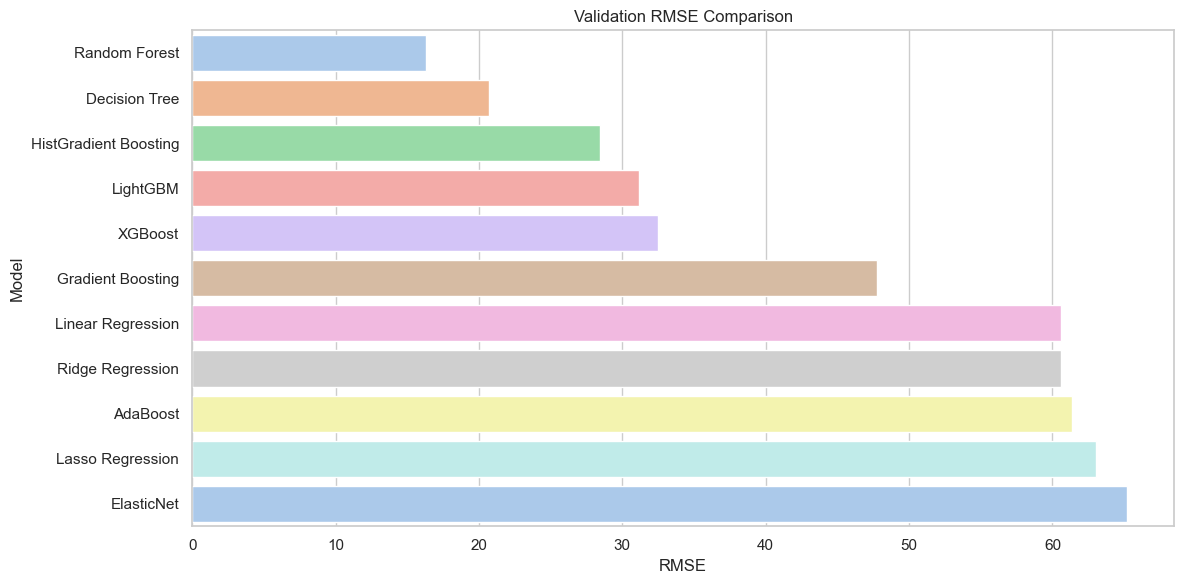

In [50]:
# Plot validation RMSE comparison

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="Validation RMSE",

    y="Model",

    palette="pastel"

)

plt.title("Validation RMSE Comparison")

plt.xlabel("RMSE")

plt.ylabel("Model")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "validation_rmse_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

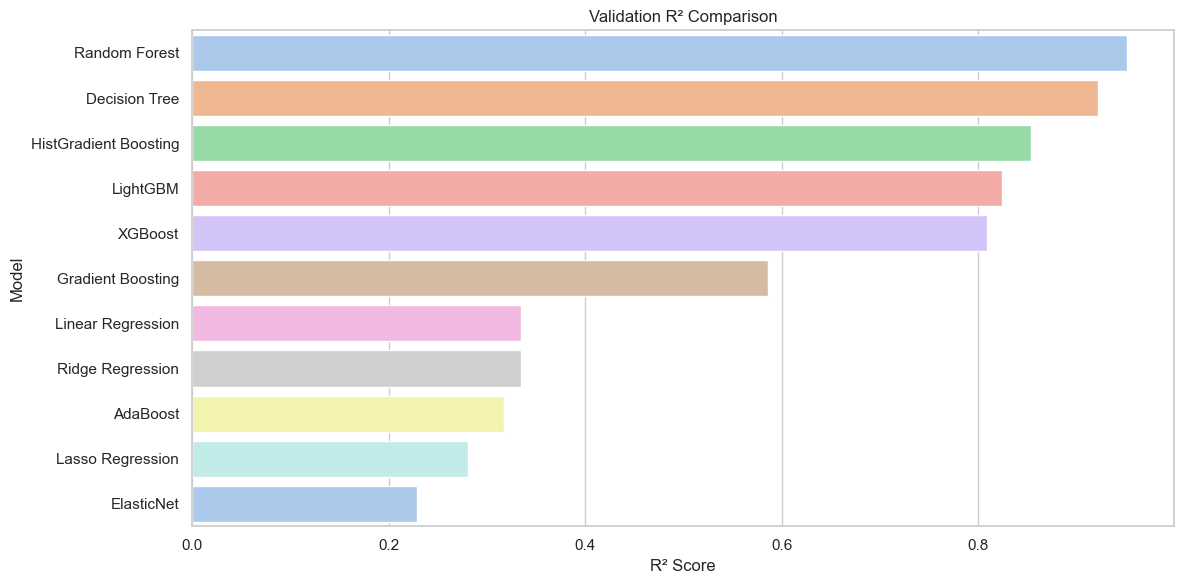

In [51]:
# Plot validation R² comparison

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="Validation R²",

    y="Model",

    palette="pastel"

)

plt.title("Validation R² Comparison")

plt.xlabel("R² Score")

plt.ylabel("Model")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "validation_r2_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

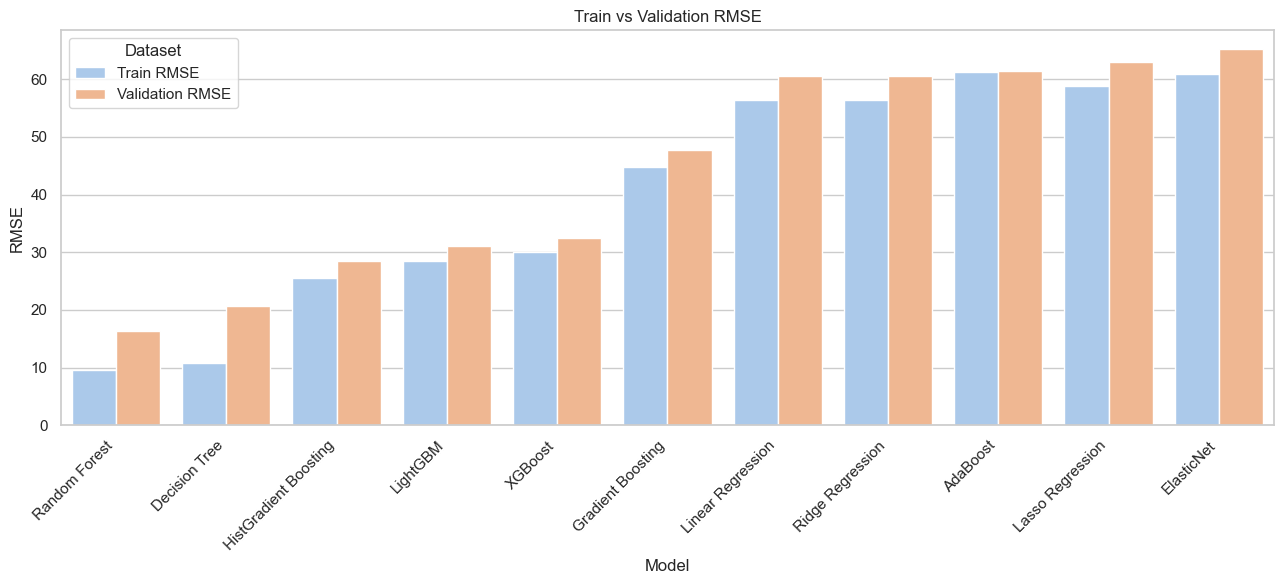

In [52]:
# Compare train and validation RMSE

comparison = results_df.melt(

    id_vars="Model",

    value_vars=[

        "Train RMSE",

        "Validation RMSE"

    ],

    var_name="Dataset",

    value_name="RMSE"

)

plt.figure(figsize=(13,6))

sns.barplot(

    data=comparison,

    x="Model",

    y="RMSE",

    hue="Dataset",

    palette="pastel"

)

plt.xticks(rotation=45, ha="right")

plt.title("Train vs Validation RMSE")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "train_validation_rmse.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Model Performance Comparison


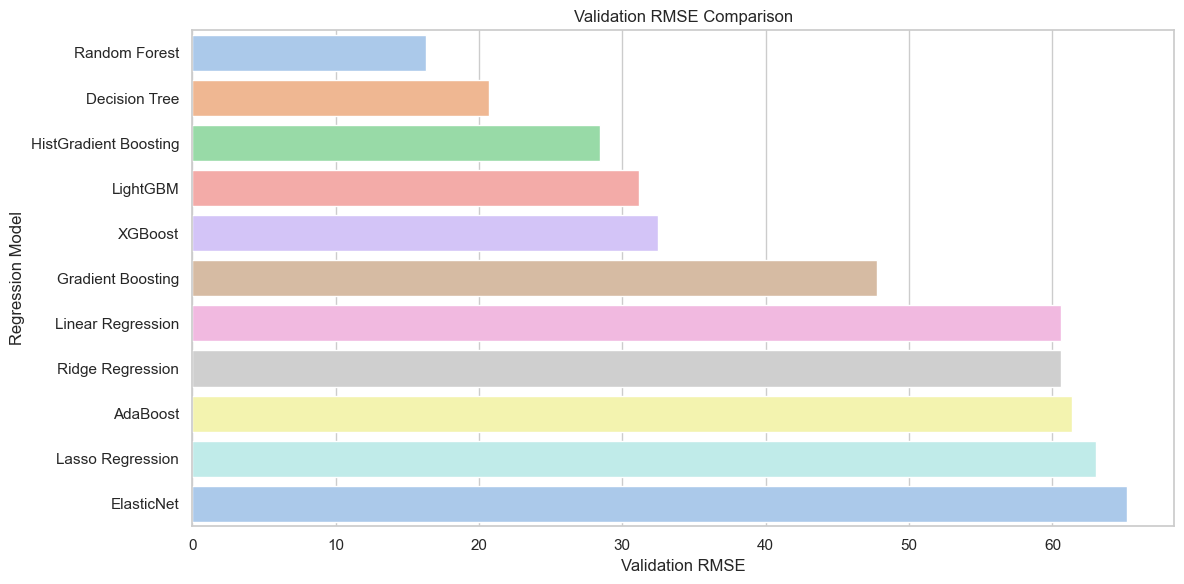

In [53]:
# Compare validation RMSE across models

plt.figure(figsize=(12, 6))

rmse_plot = results_df.sort_values("Validation RMSE")

sns.barplot(

    data=rmse_plot,

    x="Validation RMSE",

    y="Model",

    palette="pastel"

)

plt.title("Validation RMSE Comparison")

plt.xlabel("Validation RMSE")

plt.ylabel("Regression Model")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "validation_rmse_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

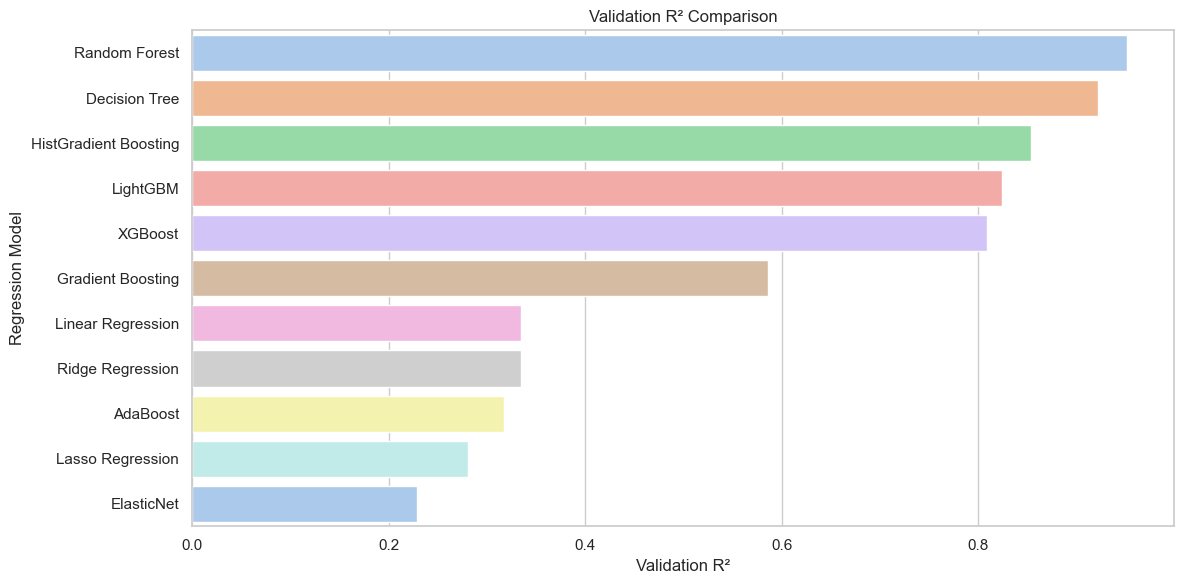

In [54]:
# Compare validation R² across models

plt.figure(figsize=(12,6))

r2_plot = results_df.sort_values(

    "Validation R²",

    ascending=False

)

sns.barplot(

    data=r2_plot,

    x="Validation R²",

    y="Model",

    palette="pastel"

)

plt.title("Validation R² Comparison")

plt.xlabel("Validation R²")

plt.ylabel("Regression Model")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "validation_r2_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

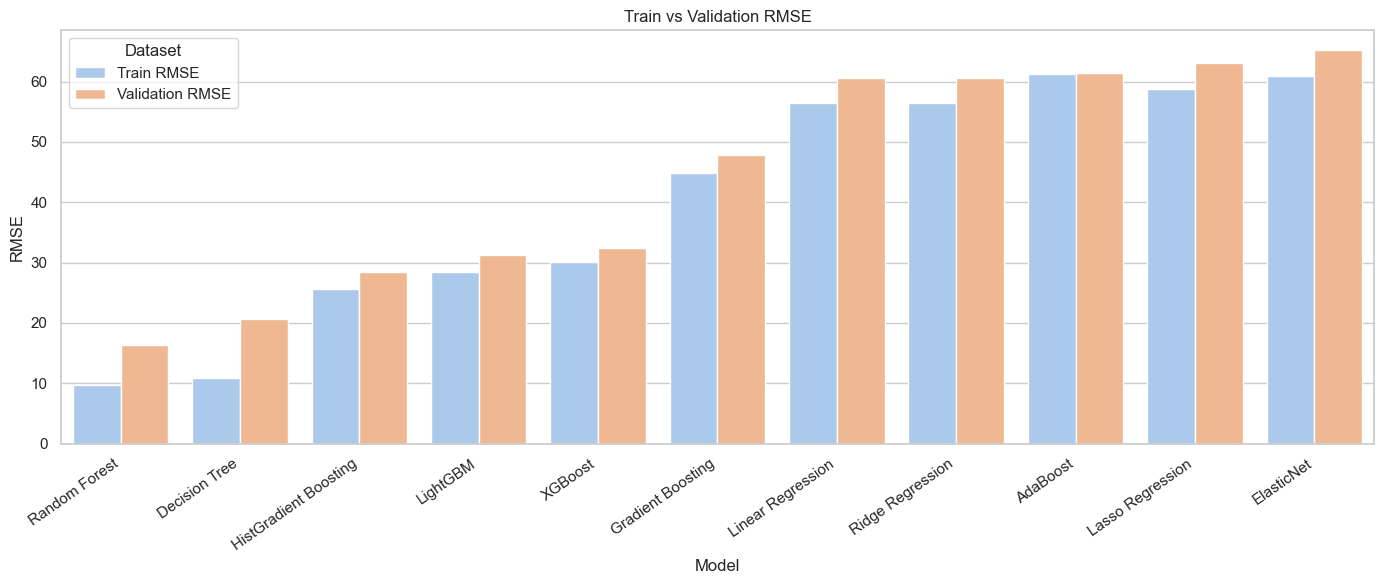

In [55]:
# Compare train and validation RMSE

rmse_compare = results_df.melt(

    id_vars="Model",

    value_vars=[

        "Train RMSE",

        "Validation RMSE"

    ],

    var_name="Dataset",

    value_name="RMSE"

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=rmse_compare,

    x="Model",

    y="RMSE",

    hue="Dataset",

    palette="pastel"

)

plt.xticks(

    rotation=35,

    ha="right"

)

plt.title("Train vs Validation RMSE")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "train_vs_validation_rmse.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

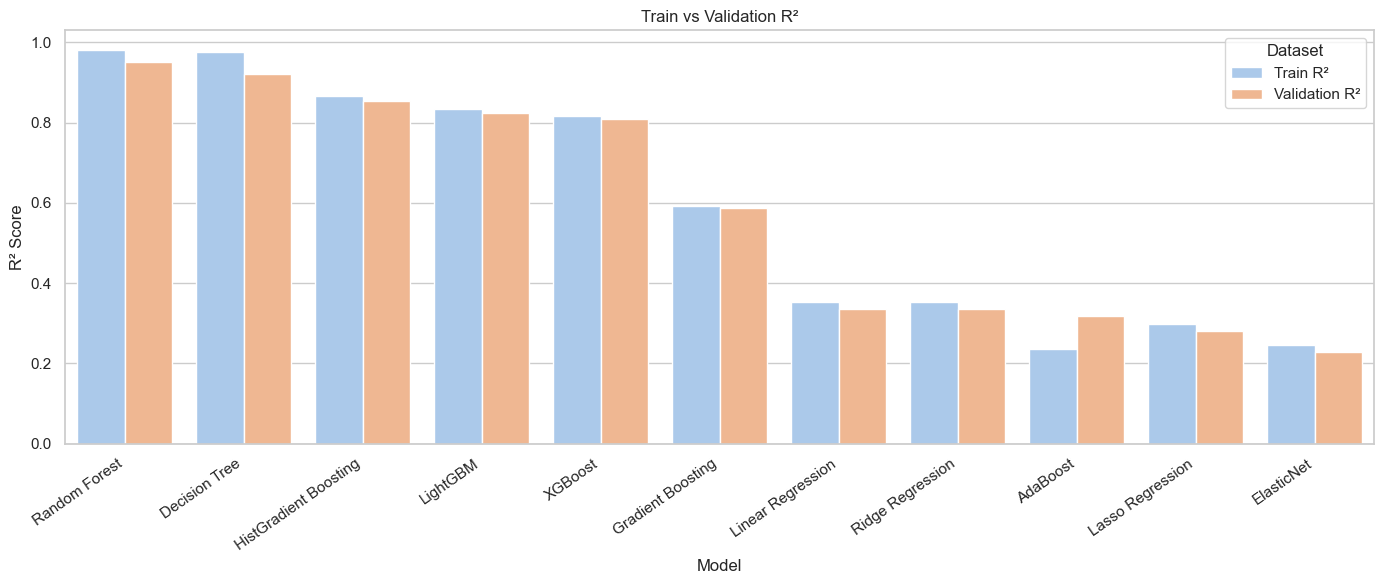

In [56]:
# Compare train and validation R²

r2_compare = results_df.melt(

    id_vars="Model",

    value_vars=[

        "Train R²",

        "Validation R²"

    ],

    var_name="Dataset",

    value_name="R² Score"

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=r2_compare,

    x="Model",

    y="R² Score",

    hue="Dataset",

    palette="pastel"

)

plt.xticks(

    rotation=35,

    ha="right"

)

plt.title("Train vs Validation R²")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "train_vs_validation_r2.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Best Model Selection


In [57]:
# Select the best regression model

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(f"Best Regression Model : {best_model_name}")

Best Regression Model : Random Forest


In [58]:
# Predict on the test dataset

test_predictions = best_model.predict(

    X_test

)

In [59]:
# Evaluate the best model on the test dataset

test_results = pd.DataFrame({

    "Metric":[

        "MAE",

        "RMSE",

        "R²",

        "MAPE"

    ],

    "Value":[

        mean_absolute_error(

            y_test,

            test_predictions

        ),

        np.sqrt(

            mean_squared_error(

                y_test,

                test_predictions

            )

        ),

        r2_score(

            y_test,

            test_predictions

        ),

        mean_absolute_percentage_error(

            y_test,

            test_predictions

        )

    ]

})

test_results

,Metric,Value
0,MAE,8.607259
1,RMSE,16.152701
2,R²,0.947199
3,MAPE,0.103103


In [60]:
# Save test evaluation results

test_results.to_csv(

    TABLE_DIR / "best_model_test_results.csv",

    index=False

)

print("Test evaluation results saved successfully.")

Test evaluation results saved successfully.


## Prediction Analysis


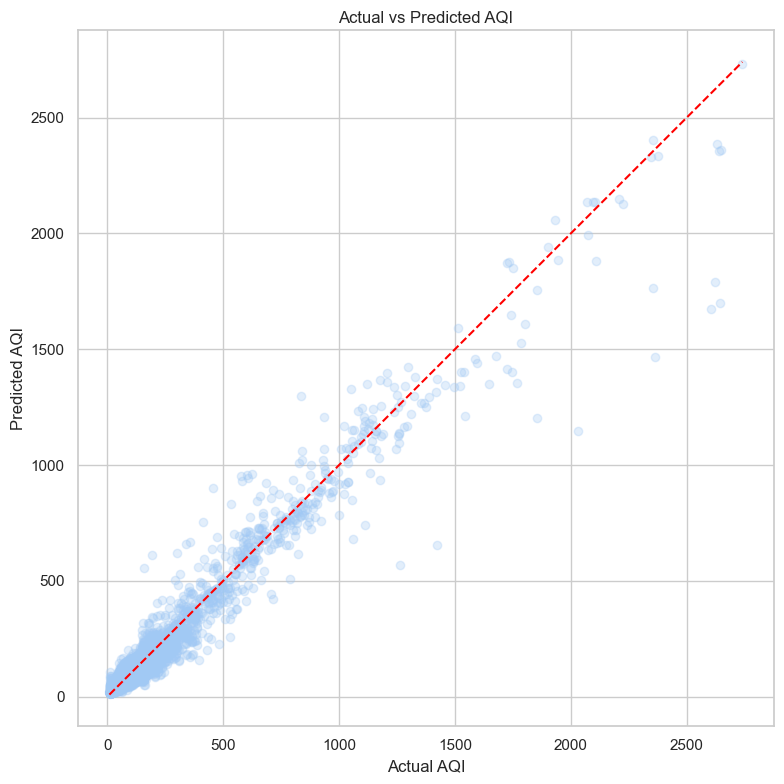

In [61]:
# Actual vs Predicted values

plt.figure(figsize=(8,8))

plt.scatter(

    y_test,

    test_predictions,

    alpha=0.3,

    color=PALETTE[0]

)

plt.plot(

    [

        y_test.min(),

        y_test.max()

    ],

    [

        y_test.min(),

        y_test.max()

    ],

    color="red",

    linestyle="--"

)

plt.title("Actual vs Predicted AQI")

plt.xlabel("Actual AQI")

plt.ylabel("Predicted AQI")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

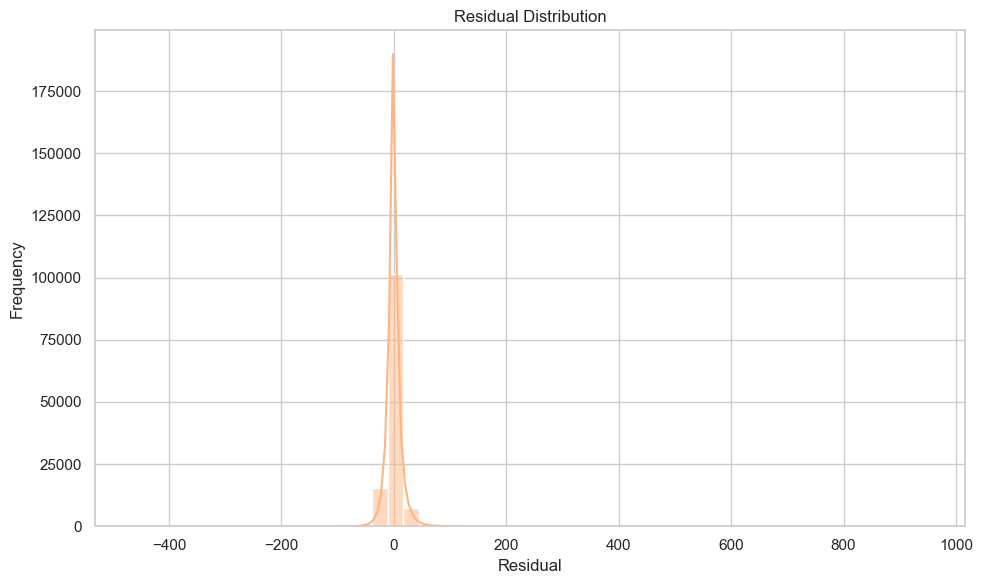

In [62]:
# Residual distribution

residuals = y_test - test_predictions

plt.figure(figsize=(10,6))

sns.histplot(

    residuals,

    bins=50,

    kde=True,

    color=PALETTE[1]

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "residual_distribution.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

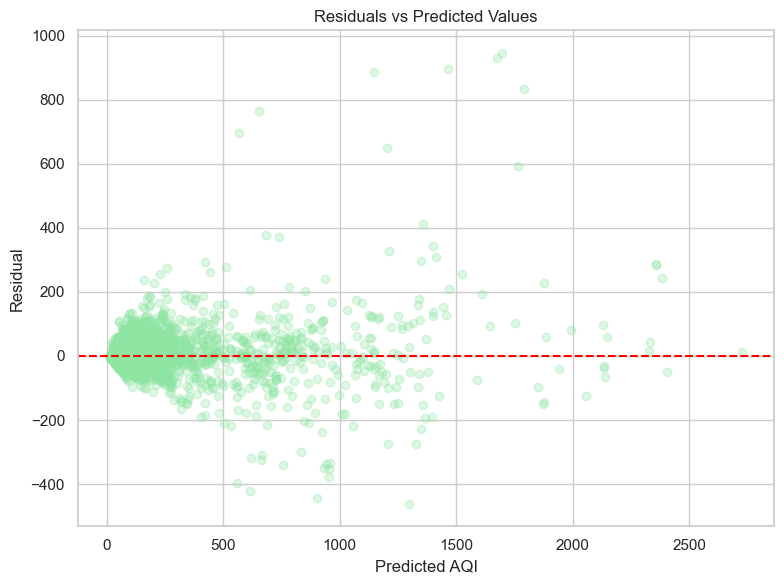

In [63]:
# Residuals vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(

    test_predictions,

    residuals,

    alpha=0.3,

    color=PALETTE[2]

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.title("Residuals vs Predicted Values")

plt.xlabel("Predicted AQI")

plt.ylabel("Residual")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "residuals_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Cross Validation


In [ ]:
# Perform K-Fold Cross Validation

kfold = KFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE

)

cv_scores = cross_val_score(

    best_model,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1

)

cv_rmse = -cv_scores

In [65]:
# Cross Validation Summary

cv_results = pd.DataFrame({

    "Fold":[

        f"Fold {i}"

        for i in range(

            1,

            len(cv_rmse)+1

        )

    ],

    "RMSE":cv_rmse

})

cv_results

,Fold,RMSE
0,Fold 1,15.447312
1,Fold 2,15.743217
2,Fold 3,14.759057
3,Fold 4,15.114264
4,Fold 5,14.178711


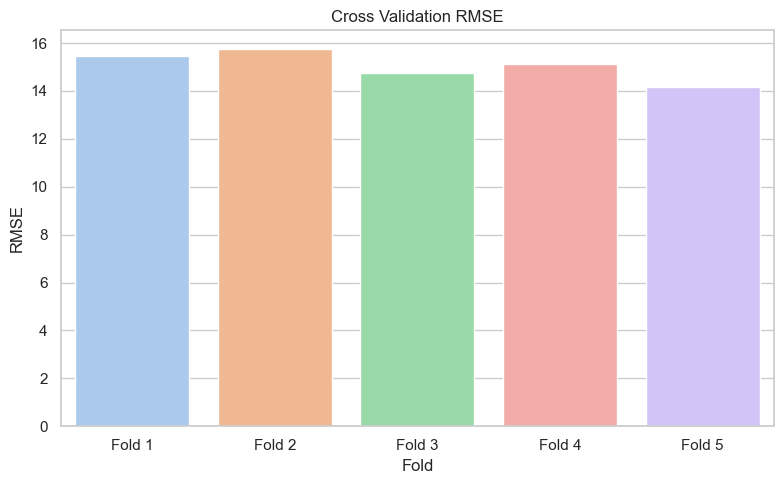

In [66]:
# Cross Validation Performance

plt.figure(figsize=(8,5))

sns.barplot(

    data=cv_results,

    x="Fold",

    y="RMSE",

    palette="pastel"

)

plt.title("Cross Validation RMSE")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "cross_validation_rmse.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [67]:
# Average Cross Validation RMSE

print(

    f"Average CV RMSE : {cv_rmse.mean():.3f}"

)

print(

    f"RMSE Standard Deviation : {cv_rmse.std():.3f}"

)

Average CV RMSE : 15.049
RMSE Standard Deviation : 0.545


## Save Final Model and Predictions

In [68]:
# Save the best regression model

joblib.dump(

    best_model,

    MODEL_DIR / "best_regression_model.pkl"

)

print("Best regression model saved successfully.")

Best regression model saved successfully.


In [69]:
# Save predictions

prediction_df = pd.DataFrame({

    "Actual AQI":y_test,

    "Predicted AQI":test_predictions,

    "Residual":residuals

})

prediction_df.to_csv(

    TABLE_DIR / "test_predictions.csv",

    index=False

)

prediction_df.head()

,Actual AQI,Predicted AQI,Residual
455850,59.0,57.576494,1.423506
679551,118.0,137.909748,-19.909748
188664,70.0,83.200386,-13.200386
62671,69.0,81.128942,-12.128942
375537,52.0,54.369963,-2.369963


## Initial Findings

In [70]:
# Regression Summary

summary = pd.DataFrame({

    "Metric":[

        "Best Model",

        "Validation RMSE",

        "Validation R²",

        "Test RMSE",

        "Test R²",

        "Average CV RMSE"

    ],

    "Value":[

        best_model_name,

        results_df.iloc[0]["Validation RMSE"],

        results_df.iloc[0]["Validation R²"],

        test_results.loc[1,"Value"],

        test_results.loc[2,"Value"],

        cv_rmse.mean()

    ]

})

summary

,Metric,Value
0,Best Model,Random Forest
1,Validation RMSE,16.294513
2,Validation R²,0.951881
3,Test RMSE,16.152701
4,Test R²,0.947199
5,Average CV RMSE,15.048512


In [71]:
# Save regression summary

summary.to_csv(

    TABLE_DIR / "regression_summary.csv",

    index=False

)

print("Regression summary saved successfully.")

Regression summary saved successfully.


# Conclusion

The regression models were successfully trained and evaluated using the feature-engineered AirIntel dataset.

Key outcomes:

- A baseline model was established for comparison.
- Multiple regression algorithms were trained using a common preprocessing pipeline.
- Models were evaluated using MAE, RMSE, R² and MAPE.
- The best-performing model was selected based on validation performance.
- Final evaluation was performed on the unseen test dataset.
- Cross-validation confirmed the stability of the selected model.
- Trained models, predictions and evaluation results were exported for downstream analysis.

The next notebook (08_Model_Comparison.ipynb) will compare regression and classification models in greater detail using comprehensive visualizations and performance analysis.

In [76]:
print("Notebook 07 Completed Successfully")
print("-" * 60)

print(f"Best Regression Model : {best_model_name}")

print(f"Validation RMSE : {results_df.iloc[0]['Validation RMSE']:.3f}")

print(f"Test RMSE : {test_results.loc[1, 'Value']:.3f}")

print(f"Test R² : {test_results.loc[2, 'Value']:.3f}")

print("-" * 60)

Notebook 07 Completed Successfully
------------------------------------------------------------
Best Regression Model : Random Forest
Validation RMSE : 16.295
Test RMSE : 16.153
Test R² : 0.947
------------------------------------------------------------
